# Overtake Probability Model — Improved Baseline

This notebook builds on the findings from **IP01** to produce a more rigorous
overtake-prediction pipeline.  Key changes versus the first baseline notebook:

| Concern | Baseline notebook | This notebook |
|---|---|---|
| Driver identity leakage | `attacker` / `defender` one-hot encoded | Dropped entirely; qualification-rank *difference* kept |
| Redundant speed columns | All three kept | Only `speed_difference` |
| High-cardinality `track` | One-hot encoded | Replaced by `track_type` + `sector_type` |
| Splitting strategy | Random 70/15/15 | `GroupKFold` by track (prevents same-circuit leakage) |
| Primary metric | Accuracy / F1 | ROC-AUC, PR-AUC, Brier score, calibration curve |
| Probability calibration | None | `CalibratedClassifierCV` (isotonic) |
| Class imbalance | Partial (`class_weight`) | `class_weight="balanced"` + threshold tuning |

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
    f1_score,
    classification_report,
    confusion_matrix,
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

## 1. Load & inspect data

In [2]:
df = pd.read_csv("../data/v1/battles_2022.csv", encoding="latin-1")
print(f"Rows: {len(df):,}")
print(f"Overtake rate: {df['overtake'].mean():.2%}")
df.head()

Rows: 35,168
Overtake rate: 4.19%


,attacker,defender,overtake,attacker_speed,defender_speed,speed_difference,lap_number,safety_car,yellow_flag,attacker_tyre_compound,...,defender_tyre_age,tyre_age_difference,track,sector,sector_type,is_in_drs_zone,drs_zone_length,track_type,attacker_qualification_rank,defender_qualification_rank
0,ALB,ALO,False,104.688,104.505,0.183,6,False,False,MEDIUM,...,6,0,AUSTIN,1,mixed,False,0,street,8,14
1,ALB,ALO,False,104.585,104.272,0.313,7,False,False,MEDIUM,...,7,0,AUSTIN,1,mixed,False,0,street,8,14
2,ALB,ALO,False,102.855,101.931,0.924,27,False,False,HARD,...,8,9,AUSTIN,1,mixed,False,0,street,15,19
3,ALB,ALO,False,103.718,103.174,0.544,34,False,False,HARD,...,12,4,AUSTIN,1,mixed,False,0,street,8,14
4,ALB,ALO,False,103.482,103.086,0.396,35,False,False,HARD,...,13,4,AUSTIN,1,mixed,False,0,street,8,14


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35168 entries, 0 to 35167
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   attacker                     35168 non-null  object 
 1   defender                     35168 non-null  object 
 2   overtake                     35168 non-null  bool   
 3   attacker_speed               35168 non-null  float64
 4   defender_speed               35168 non-null  float64
 5   speed_difference             35168 non-null  float64
 6   lap_number                   35168 non-null  int64  
 7   safety_car                   35168 non-null  bool   
 8   yellow_flag                  35168 non-null  bool   
 9   attacker_tyre_compound       35103 non-null  object 
 10  defender_tyre_compound       35122 non-null  object 
 11  attacker_tyre_age            35168 non-null  int64  
 12  defender_tyre_age            35168 non-null  int64  
 13  tyre_age_differe

In [4]:
df.describe()

,attacker_speed,defender_speed,speed_difference,lap_number,attacker_tyre_age,defender_tyre_age,tyre_age_difference,sector,drs_zone_length,attacker_qualification_rank,defender_qualification_rank
count,35168.000000,35168.000000,35168.000000,35168.000000,35168.000000,35168.000000,35168.000000,35168.0,35168.000000,35168.000000,35168.000000
mean,90.773045,90.719620,0.053425,29.506796,14.568983,15.100375,3.455073,1.0,7.067931,10.460532,9.607513
std,11.583294,11.588762,0.421477,18.516269,10.214756,10.470700,5.598268,0.0,50.298222,5.543211,5.612717
min,73.837000,73.652000,-0.999000,1.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000
25%,82.146750,82.053000,-0.197000,13.000000,7.000000,7.000000,0.000000,1.0,0.000000,6.000000,5.000000
50%,87.837000,87.790000,0.054000,28.000000,12.000000,13.000000,1.000000,1.0,0.000000,10.000000,9.000000
75%,98.310000,98.262250,0.328000,44.000000,20.000000,21.000000,4.000000,1.0,0.000000,15.000000,14.000000
max,149.942000,149.884000,0.999000,78.000000,78.000000,78.000000,56.000000,1.0,365.000000,20.000000,20.000000


### 1.1 Class distribution

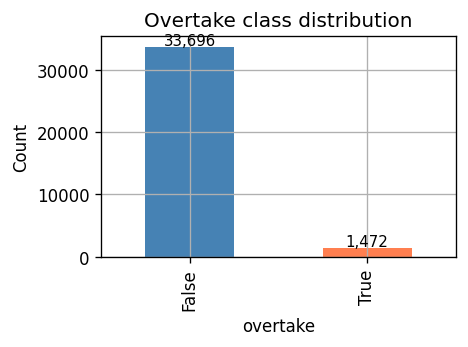

In [5]:
counts = df["overtake"].value_counts()
fig, ax = plt.subplots(figsize=(4, 3))
counts.plot.bar(ax=ax, color=["steelblue", "coral"])
ax.set_title("Overtake class distribution")
ax.set_ylabel("Count")
for i, v in enumerate(counts):
    ax.text(i, v + 200, f"{v:,}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

### 1.2 Overtake rate by track

In [6]:
track_stats = (
    df.groupby("track")["overtake"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "overtake_rate", "count": "n_battles"})
    .sort_values("overtake_rate", ascending=False)
)
track_stats.style.format({"overtake_rate": "{:.2%}", "n_battles": "{:,}"})

,overtake_rate,n_battles
track,,
SPA-FRANCORCHAMPS,7.47%,950
BARCELONA,5.31%,"2,336"
MONZA,5.24%,"2,539"
YAS ISLAND,5.20%,"2,018"
SUZUKA,5.06%,"1,086"
MELBOURNE,4.81%,"2,098"
AUSTIN,4.65%,"1,805"
LE CASTELLET,4.55%,703
BAKU,4.45%,"1,169"


## 2. Feature engineering

Following IP01 recommendations:
- **Drop** `attacker`, `defender` (driver identity leakage)
- **Drop** `attacker_speed`, `defender_speed` (redundant with `speed_difference`)
- **Drop** `track` (replaced by `track_type` and `sector_type`)
- **Add** `qualification_rank_difference` (attacker − defender)
- Keep remaining contextual features

In [7]:
df["qualification_rank_difference"] = (
    df["attacker_qualification_rank"] - df["defender_qualification_rank"]
)

DROP_COLS = [
    "attacker",
    "defender",
    "attacker_speed",
    "defender_speed",
    "track",
    "attacker_qualification_rank",
    "defender_qualification_rank",
    "overtake",
]

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
TARGET = "overtake"

print("Features used:", FEATURE_COLS)
print(f"Number of features: {len(FEATURE_COLS)}")

Features used: ['speed_difference', 'lap_number', 'safety_car', 'yellow_flag', 'attacker_tyre_compound', 'defender_tyre_compound', 'attacker_tyre_age', 'defender_tyre_age', 'tyre_age_difference', 'sector', 'sector_type', 'is_in_drs_zone', 'drs_zone_length', 'track_type', 'qualification_rank_difference']
Number of features: 15


In [8]:
X = df[FEATURE_COLS].copy()
y = df[TARGET].astype(int).values
groups = df["track"].values  # for GroupKFold

cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

print(f"Categorical: {cat_cols}")
print(f"Numeric:     {num_cols}")

Categorical: ['safety_car', 'yellow_flag', 'attacker_tyre_compound', 'defender_tyre_compound', 'sector_type', 'is_in_drs_zone', 'track_type']
Numeric:     ['speed_difference', 'lap_number', 'attacker_tyre_age', 'defender_tyre_age', 'tyre_age_difference', 'sector', 'drs_zone_length', 'qualification_rank_difference']


## 3. Preprocessing pipeline

In [9]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ]
)

## 4. Model definitions

Three classifiers of increasing complexity, all with `class_weight="balanced"`.

In [10]:
MODELS = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced", max_iter=2000, solver="lbfgs"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        max_depth=12,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        min_samples_leaf=20,
        random_state=42,
    ),
}

## 5. Evaluation via GroupKFold (by track)

Using `GroupKFold` with `track` as the grouping variable ensures that all
battles from a given circuit stay in the same fold, preventing within-circuit
leakage and better approximating generalisation to unseen tracks.

In [11]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

results = {}

for name, clf in MODELS.items():
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")

    pipe = Pipeline([("preprocess", preprocessor), ("classifier", clf)])

    probas = cross_val_predict(
        pipe, X, y, cv=gkf, groups=groups, method="predict_proba", n_jobs=1
    )[:, 1]

    roc_auc = roc_auc_score(y, probas)
    pr_auc = average_precision_score(y, probas)
    brier = brier_score_loss(y, probas)

    preds = (probas >= 0.5).astype(int)
    f1 = f1_score(y, preds)

    results[name] = {
        "probas": probas,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Brier": brier,
        "F1 (t=0.5)": f1,
    }

    print(f"  ROC-AUC : {roc_auc:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    print(f"  Brier   : {brier:.4f}")
    print(f"  F1@0.5  : {f1:.4f}")


  Logistic Regression


  ROC-AUC : 0.7559
  PR-AUC  : 0.1141
  Brier   : 0.2054
  F1@0.5  : 0.1534

  Random Forest


  ROC-AUC : 0.7663
  PR-AUC  : 0.1218
  Brier   : 0.1426
  F1@0.5  : 0.1872

  Gradient Boosting


  ROC-AUC : 0.7571
  PR-AUC  : 0.1135
  Brier   : 0.0394
  F1@0.5  : 0.0118


### 5.1 Summary table

In [12]:
summary = pd.DataFrame(
    {k: {m: v for m, v in v.items() if m != "probas"} for k, v in results.items()}
).T
summary.style.format("{:.4f}").highlight_min(
    subset=["Brier"], color="#d4edda"
).highlight_max(
    subset=["ROC-AUC", "PR-AUC", "F1 (t=0.5)"], color="#d4edda"
)

,ROC-AUC,PR-AUC,Brier,F1 (t=0.5)
Logistic Regression,0.7559,0.1141,0.2054,0.1534
Random Forest,0.7663,0.1218,0.1426,0.1872
Gradient Boosting,0.7571,0.1135,0.0394,0.0118


## 6. ROC & Precision-Recall curves

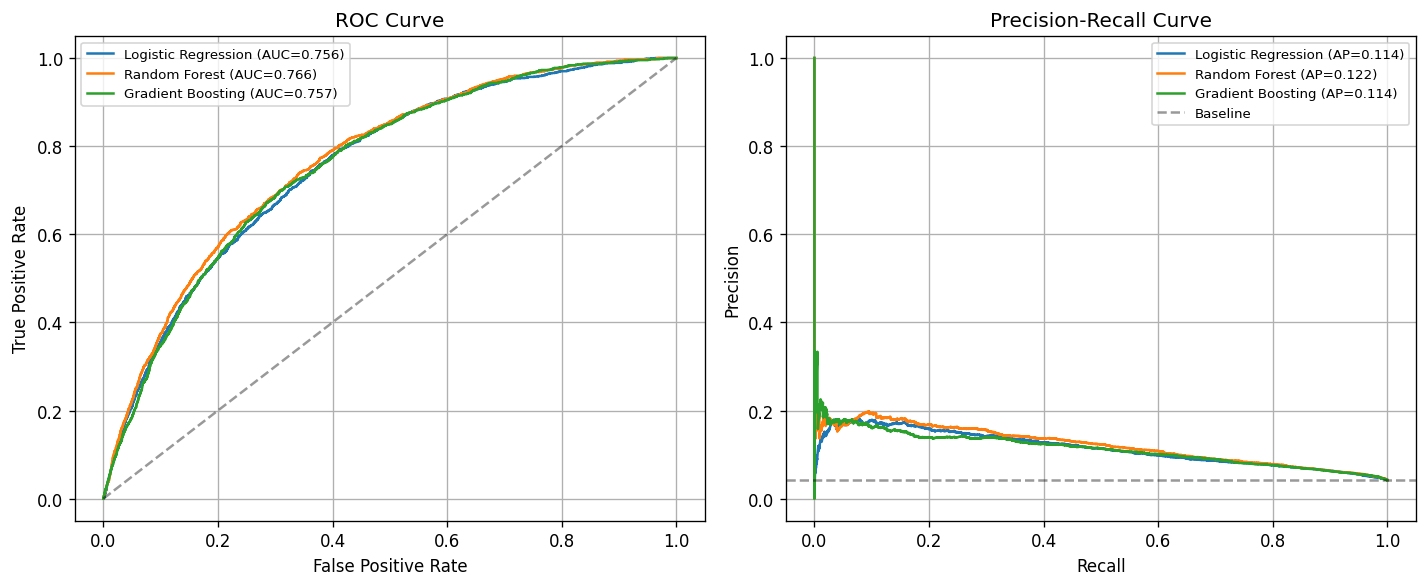

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y, res["probas"])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['ROC-AUC']:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend(fontsize=8)

for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y, res["probas"])
    axes[1].plot(rec, prec, label=f"{name} (AP={res['PR-AUC']:.3f})")

axes[1].axhline(y=y.mean(), color="k", ls="--", alpha=0.4, label="Baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 7. Calibration analysis

Good probability estimates are essential for this use-case.  A well-calibrated
model should have its reliability curve close to the diagonal.

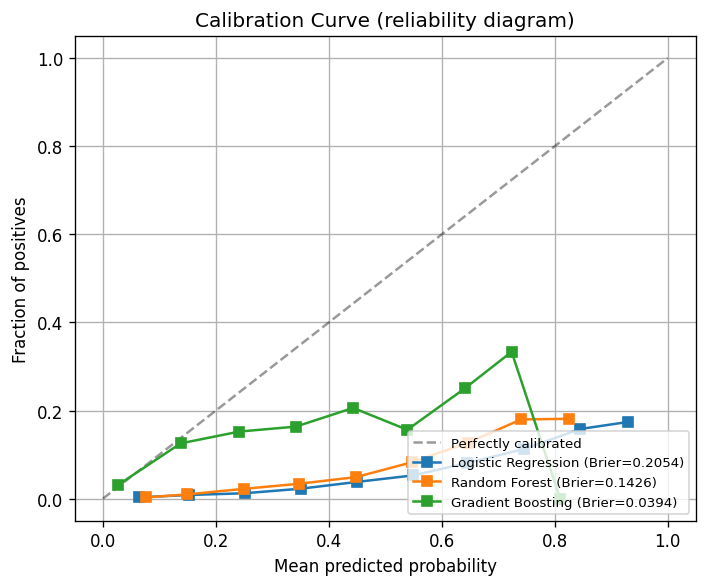

In [14]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")

for name, res in results.items():
    frac_pos, mean_pred = calibration_curve(y, res["probas"], n_bins=10, strategy="uniform")
    ax.plot(mean_pred, frac_pos, "s-", label=f"{name} (Brier={res['Brier']:.4f})")

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve (reliability diagram)")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 8. Threshold tuning

The default 0.5 threshold is arbitrary for imbalanced problems.  We sweep
thresholds and pick the one maximising F1 on the cross-validated probabilities.

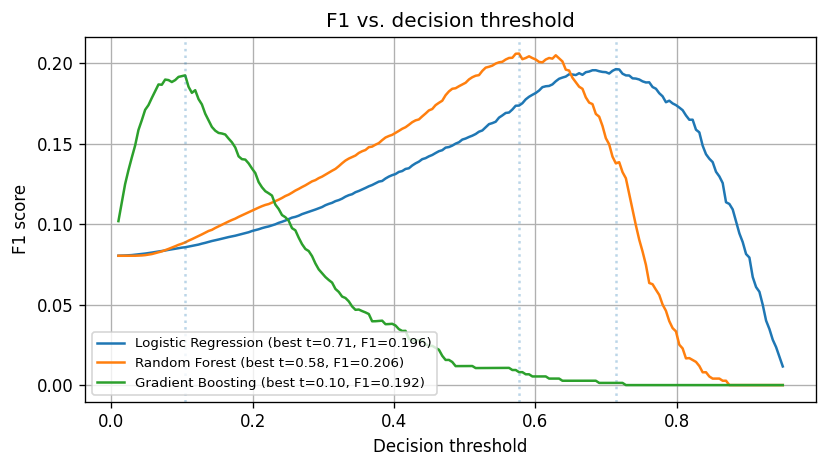


Logistic Regression @ threshold=0.71
              precision    recall  f1-score   support

 No overtake       0.97      0.91      0.94     33696
    Overtake       0.14      0.32      0.20      1472

    accuracy                           0.89     35168
   macro avg       0.55      0.62      0.57     35168
weighted avg       0.93      0.89      0.91     35168


Random Forest @ threshold=0.58
              precision    recall  f1-score   support

 No overtake       0.97      0.89      0.93     33696
    Overtake       0.14      0.41      0.21      1472

    accuracy                           0.87     35168
   macro avg       0.55      0.65      0.57     35168
weighted avg       0.94      0.87      0.90     35168


Gradient Boosting @ threshold=0.10
              precision    recall  f1-score   support

 No overtake       0.97      0.91      0.94     33696
    Overtake       0.14      0.31      0.19      1472

    accuracy                           0.89     35168
   macro avg       0.5

In [15]:
fig, ax = plt.subplots(figsize=(7, 4))

best_thresholds = {}

for name, res in results.items():
    thresholds = np.linspace(0.01, 0.95, 200)
    f1s = [f1_score(y, (res["probas"] >= t).astype(int), zero_division=0) for t in thresholds]
    best_idx = np.argmax(f1s)
    best_t = thresholds[best_idx]
    best_f1 = f1s[best_idx]
    best_thresholds[name] = best_t

    ax.plot(thresholds, f1s, label=f"{name} (best t={best_t:.2f}, F1={best_f1:.3f})")
    ax.axvline(best_t, ls=":", alpha=0.3)

ax.set_xlabel("Decision threshold")
ax.set_ylabel("F1 score")
ax.set_title("F1 vs. decision threshold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

for name, t in best_thresholds.items():
    preds = (results[name]["probas"] >= t).astype(int)
    print(f"\n{name} @ threshold={t:.2f}")
    print(classification_report(y, preds, target_names=["No overtake", "Overtake"]))

## 9. Calibrated model (isotonic regression)

We retrain the best-performing model with `CalibratedClassifierCV` to produce
better-calibrated probability outputs.

In [16]:
best_model_name = max(results, key=lambda k: results[k]["ROC-AUC"])
print(f"Best model by ROC-AUC: {best_model_name}")

X_transformed = preprocessor.fit_transform(X)

base_clf = MODELS[best_model_name]
cal_clf = CalibratedClassifierCV(base_clf, method="isotonic", cv=5)
cal_clf.fit(X_transformed, y)

cal_probas = cal_clf.predict_proba(X_transformed)[:, 1]
cal_brier = brier_score_loss(y, cal_probas)

print(f"Calibrated Brier score (in-sample): {cal_brier:.4f}")
print(f"Original Brier score (CV):          {results[best_model_name]['Brier']:.4f}")

Best model by ROC-AUC: Random Forest


Calibrated Brier score (in-sample): 0.0356
Original Brier score (CV):          0.1426


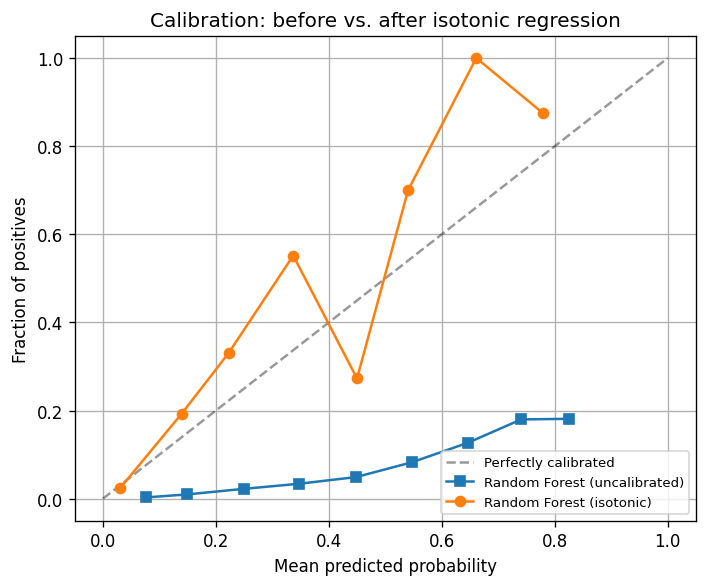

In [17]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Perfectly calibrated")

frac_pos_orig, mean_pred_orig = calibration_curve(
    y, results[best_model_name]["probas"], n_bins=10, strategy="uniform"
)
ax.plot(mean_pred_orig, frac_pos_orig, "s-", label=f"{best_model_name} (uncalibrated)")

frac_pos_cal, mean_pred_cal = calibration_curve(
    y, cal_probas, n_bins=10, strategy="uniform"
)
ax.plot(mean_pred_cal, frac_pos_cal, "o-", label=f"{best_model_name} (isotonic)")

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration: before vs. after isotonic regression")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

## 10. Feature importance

Inspect which features the best tree-based model relies on most.

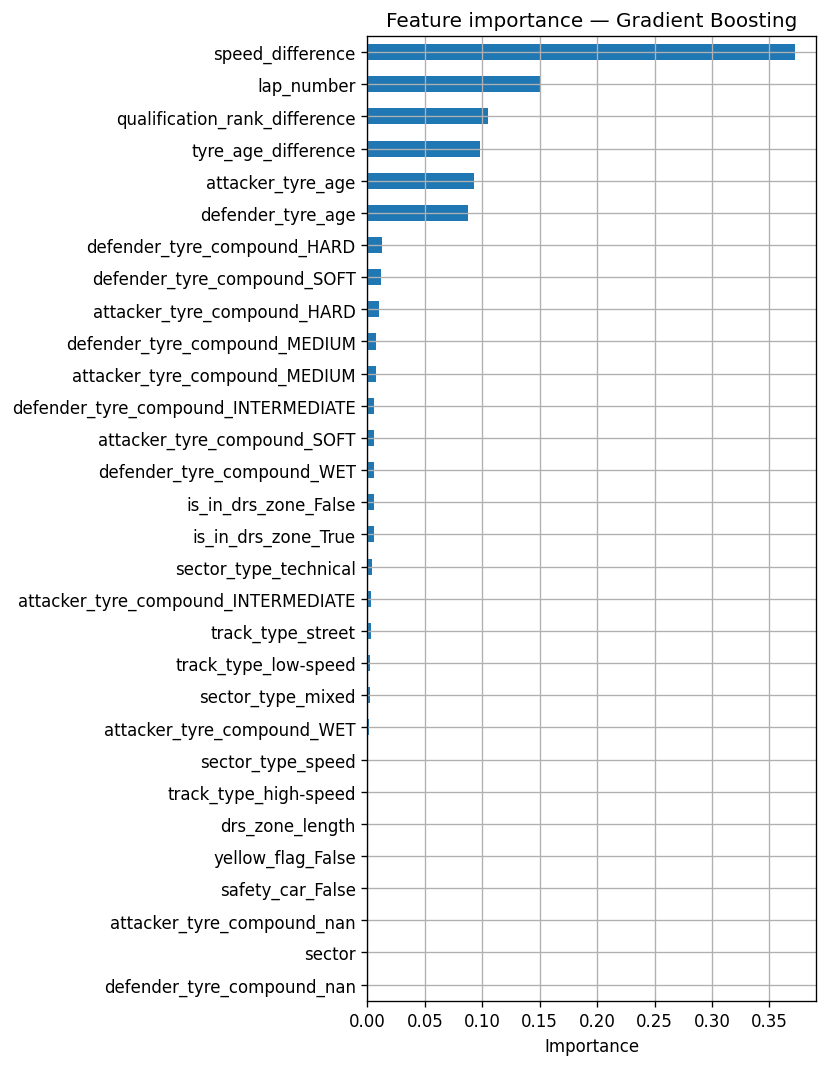

In [18]:
tree_name = "Gradient Boosting" if "Gradient Boosting" in MODELS else "Random Forest"
tree_pipe = Pipeline([("preprocess", preprocessor), ("classifier", MODELS[tree_name])])
tree_pipe.fit(X, y)

ohe_features = (
    tree_pipe.named_steps["preprocess"]
    .named_transformers_["cat"]
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_feature_names = num_cols + ohe_features

importances = tree_pipe.named_steps["classifier"].feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, max(4, len(feat_imp) * 0.3)))
feat_imp.plot.barh(ax=ax)
ax.set_title(f"Feature importance — {tree_name}")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 11. Confusion matrix (best model, tuned threshold)

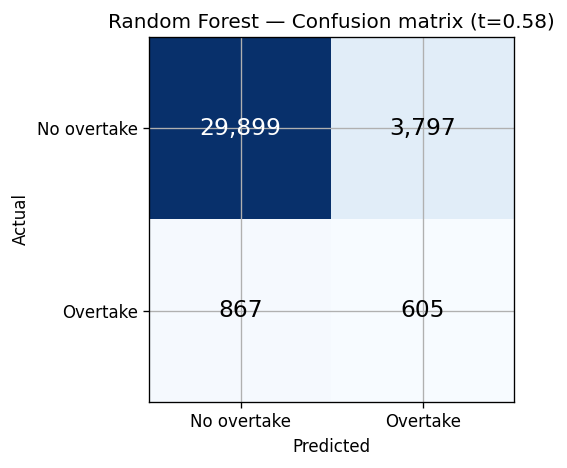

In [19]:
best_t = best_thresholds[best_model_name]
best_preds = (results[best_model_name]["probas"] >= best_t).astype(int)

cm = confusion_matrix(y, best_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["No overtake", "Overtake"])
ax.set_yticklabels(["No overtake", "Overtake"])
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"{best_model_name} — Confusion matrix (t={best_t:.2f})")

for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=14)

plt.tight_layout()
plt.show()

## 12. Takeaways

- **ROC-AUC & PR-AUC** give a much more honest picture than accuracy for this
  heavily imbalanced dataset (~4% positive class).
- **GroupKFold by track** prevents within-circuit leakage and tests how well the
  model generalises to circuits it has never seen.
- **Dropping driver identity** forces the model to learn *physics-based* overtaking
  patterns rather than *who* overtakes.
- **Calibration** (isotonic) can improve probability reliability but should be
  validated on a held-out set to avoid in-sample bias.

### Next steps
- Add a season/year column to the data to enable proper temporal train/test splits.
- Experiment with derived features: e.g. tyre-compound advantage encoding,
  normalised lap number (lap / total laps).
- Hyperparameter search with Optuna / RandomizedSearchCV using PR-AUC as the
  scoring metric.
- Evaluate with `GroupKFold` by **race** once race IDs are available.